<a href="https://colab.research.google.com/github/LindsayRendon/campaigns-demo/blob/master/01_CNN_CIFAR10_Clasificacion_Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Título del ejercicio: Clasificación de imágenes con CNN usando CIFAR-10

## 2. Objetivo
Entrenar una Red Neuronal Convolucional (CNN) capaz de identificar y clasificar correctamente imágenes pequeñas en 10 categorías distintas.

## 3. Qué problema resuelve
La clasificación manual de imágenes es una tarea lenta y propensa a errores cuando se trata de miles o millones de datos. Este modelo resuelve el problema de la automatización visual, permitiendo a una computadora "ver" una imagen y asignarle una etiqueta precisa de forma casi instantánea.

## 4. Dataset usado
**CIFAR-10**. Es un conjunto de datos estándar en Computer Vision. Contiene 60,000 imágenes en color de 32x32 píxeles, divididas en 10 clases (avión, coche, pájaro, gato, ciervo, perro, rana, caballo, barco y camión). Hay 50,000 imágenes para entrenamiento y 10,000 para evaluación.

---
### Conceptos teóricos clave aplicados en este Notebook:

* **¿Qué es una convolución?** Es una operación matemática donde una pequeña matriz (el filtro) se desliza sobre la imagen original multiplicando los valores de los píxeles. Su objetivo es extraer características de la imagen, como bordes, colores o texturas.
* **¿Qué hace un kernel/filtro?** Es la matriz que se desliza sobre la imagen en la convolución. Dependiendo de sus valores, un filtro puede detectar líneas verticales, otro líneas horizontales, etc. La red aprende automáticamente los mejores valores para estos filtros durante el entrenamiento.
* **¿Qué hace el pooling?** Es una técnica de reducción de tamaño (submuestreo). Agrupa píxeles cercanos y se queda con el valor más importante (por ejemplo, el valor máximo en *Max Pooling*). Esto reduce la cantidad de datos que la red debe procesar y ayuda a que el modelo reconozca un objeto sin importar si está un poco movido en la imagen.
* **¿Por qué CNN es adecuada para imágenes?** Las redes densas tradicionales estiran la imagen en una sola línea, perdiendo la relación espacial (qué píxel está arriba o al lado de otro). Las CNN mantienen la estructura 2D de la imagen y buscan patrones visuales en diferentes partes de la foto.
* **Diferencia entre clasificación, detección y segmentación:**
    * *Clasificación:* Dice qué hay en la imagen (Ej. "Es un perro"). Es lo que haremos aquí.
    * *Detección:* Dice qué hay y dibuja una caja (bounding box) alrededor del objeto.
    * *Segmentación:* Clasifica cada píxel de la imagen, dibujando la silueta exacta del objeto.


In [1]:
# 5. Librerías
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Librerías cargadas correctamente. Versión de TensorFlow:", tf.__version__)

Librerías cargadas correctamente. Versión de TensorFlow: 2.20.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


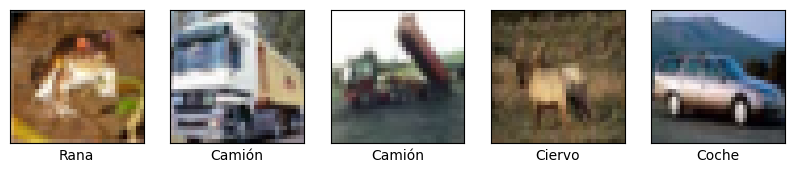

In [2]:
# 6. Carga y exploración de datos
# CIFAR-10 se descarga directamente desde Keras
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Nombres de las 10 clases para que sea más fácil leer los resultados
class_names = ['Avión', 'Coche', 'Pájaro', 'Gato', 'Ciervo',
               'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Vamos a explorar cómo se ven las primeras 5 imágenes
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # train_labels es un array 2D, sacamos el índice con [i][0]
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [3]:
# 7. Preprocesamiento (Normalizar los datos para que la red aprenda mejorr)
# Los píxeles tienen valores entre 0 y 255. Los dividimos entre 255.0 para
# normalizarlos y que queden en un rango de 0 a 1.
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Datos normalizados. Tamaño del set de entrenamiento:", train_images.shape)

Datos normalizados. Tamaño del set de entrenamiento: (50000, 32, 32, 3)


In [4]:
# 8. Modelo (Aquí creamos la arquitectura de la red convolucional)
model = models.Sequential()

# Capa Convolucional 1 + Pooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Capa Convolucional 2 + Pooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Capa Convolucional 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Aplanamos los datos para pasarlos a una red neuronal tradicional (Densa)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

# Capa de salida: 10 neuronas (una por cada clase) con activación softmax para obtener probabilidades
model.add(layers.Dense(10, activation='softmax'))

# Ver el resumen de la arquitectura
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 9. Entrenamiento (Entrenamos la red)
# Compilamos el modelo indicando el optimizador y cómo medir el error
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos durante 10 épocas (pasadas completas al dataset)
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.4456 - loss: 1.5201 - val_accuracy: 0.5606 - val_loss: 1.2457
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5967 - loss: 1.1359 - val_accuracy: 0.6129 - val_loss: 1.1160
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6492 - loss: 0.9952 - val_accuracy: 0.6610 - val_loss: 0.9755
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6849 - loss: 0.8997 - val_accuracy: 0.6642 - val_loss: 0.9701
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7069 - loss: 0.8325 - val_accuracy: 0.6698 - val_loss: 0.9527
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7258 - loss: 0.7771 - val_accuracy: 0.6901 - val_loss: 0.9116
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7434 - loss: 0.7269 - val_accuracy: 0.6929 - val_loss: 0.9013
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7571 - loss: 0.6891 

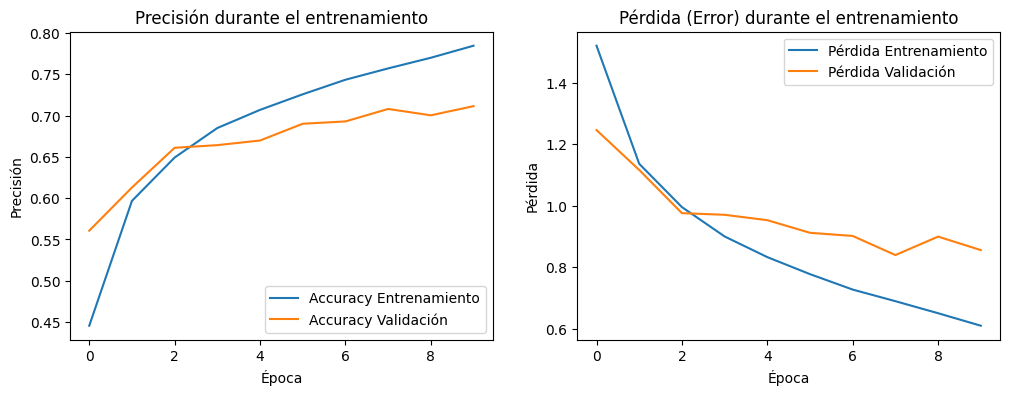

313/313 - 1s - 2ms/step - accuracy: 0.7114 - loss: 0.8553
\nPrecisión final en datos de Test: 71.14%


In [6]:
# 10. Evaluación: Gráficas de Accuracy y Pérdida
plt.figure(figsize=(12, 4))

# Gráfica de Accuracy (Precisión)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy Validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')

# Gráfica de Loss (Pérdida)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Pérdida (Error) durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')

plt.show()

# Evaluación final en el set de test
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\\nPrecisión final en datos de Test: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


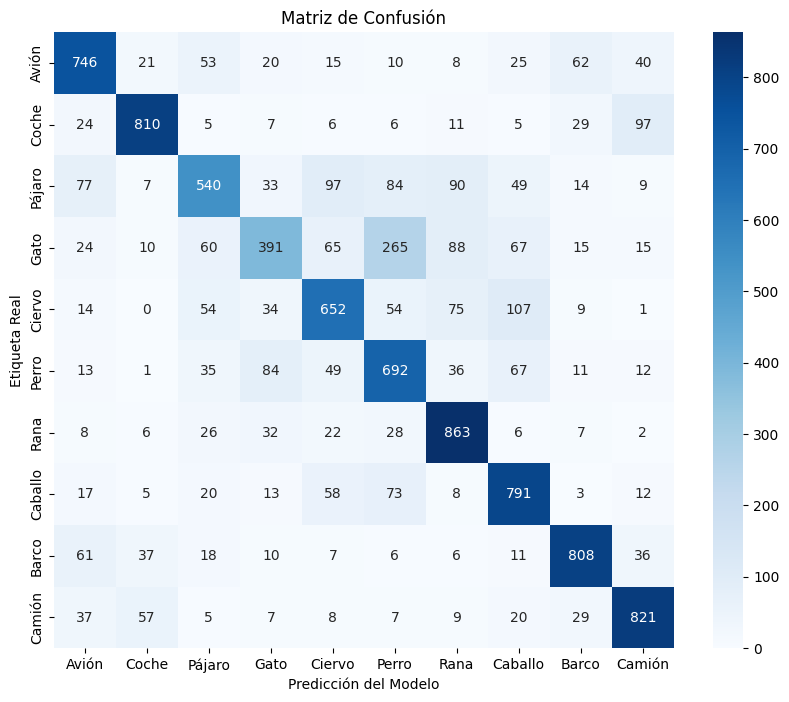

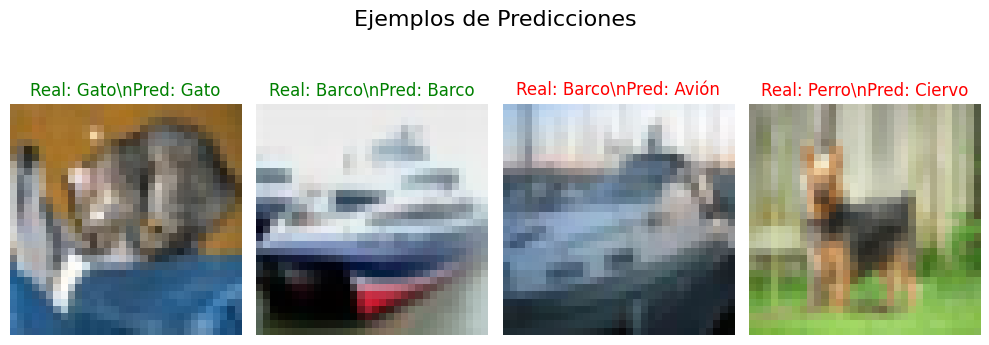

In [7]:
# Evaluación: Matriz de confusión e imágenes correctas/incorrectas
# Hacemos predicciones con el set de prueba
predictions = model.predict(test_images)
# Extraemos la clase con mayor probabilidad
pred_labels = np.argmax(predictions, axis=1)
true_labels = test_labels.flatten()

# 1. Matriz de confusión
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

# 2. Mostrar imágenes con predicción correcta e incorrecta
correct_idx = np.where(pred_labels == true_labels)[0]
incorrect_idx = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(10, 4))
plt.suptitle("Ejemplos de Predicciones", fontsize=16)

# Mostrar 2 correctas
for i in range(2):
    plt.subplot(1, 4, i+1)
    idx = correct_idx[i]
    plt.imshow(test_images[idx])
    plt.title(f"Real: {class_names[true_labels[idx]]}\\nPred: {class_names[pred_labels[idx]]}", color='green')
    plt.axis('off')

# Mostrar 2 incorrectas
for i in range(2):
    plt.subplot(1, 4, i+3)
    idx = incorrect_idx[i]
    plt.imshow(test_images[idx])
    plt.title(f"Real: {class_names[true_labels[idx]]}\\nPred: {class_names[pred_labels[idx]]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 11. Conclusión
El modelo de Red Neuronal Convolucional ha logrado aprender patrones de imágenes complejas (a color) alcanzando una precisión razonable en solo 10 épocas. A través de las gráficas observamos que el modelo aprende rápidamente en las primeras pasadas. En la matriz de confusión podemos identificar en qué categorías el modelo suele confundirse más (por ejemplo, es común que confunda a un perro con un gato, o a un coche con un camión, debido a las similitudes visuales en baja resolución).

## 12. Qué aprendí
* **Eficacia de las convoluciones:** He comprobado de forma práctica que las capas `Conv2D` combinadas con `MaxPooling2D` extraen exitosamente las características importantes (orejas, ruedas, alas) sin que yo tenga que programar reglas manuales sobre dónde está el objeto en la foto.
* **Sobreajuste (Overfitting):** Al observar las gráficas de pérdida y precisión, pude entender la importancia de tener un conjunto de validación separado. Si la línea de entrenamiento sigue mejorando pero la de validación se estanca o empeora, sabré que mi red está empezando a memorizar (sobreajustar) en lugar de generalizar.
* **Análisis de errores:** La matriz de confusión me demostró que el modelo no se equivoca al azar. Los errores tienen un sentido visual humano (confundir animales de 4 patas entre sí), lo que refuerza el concepto de que la CNN está aprendiendo formas geométricas y texturas reales.

